# Chapter 5: Differential Privacy for Generative Models

**Chapter 5: Synthetic Data Generation**
**Section Reference**: Section 5.7 (Validation: The Fidelity-Utility-Privacy Framework)

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 05_synthetic_data/07_dp_gan.py
> ```


## Purpose

This notebook demonstrates **Differential Privacy (DP)** for training generative models
using **Opacus**, PyTorch's official DP library. We train a GAN with formal privacy
guarantees that limit information leakage about individual records.

## Learning Objectives

By completing this notebook, you will:
- Understand the differential privacy framework and privacy budget (ε)
- Implement DP-SGD training using Opacus (proper per-sample gradients)
- Observe the privacy-utility tradeoff as ε varies
- Evaluate synthetic data quality under privacy constraints

## Cross-References

- **Upstream**: ETF Universe loader (`data`)
- **Book**: Section 5.7 discusses differential privacy in the FUP framework

---

## Key Concepts

1. **Differential Privacy**: Mathematical framework for privacy guarantees
2. **DP-SGD**: Per-sample gradient clipping + noise (NOT batch-level)
3. **Privacy Budget (ε)**: Trade-off between privacy and utility
4. **Privacy Accountant**: Tracks cumulative privacy cost during training

## Why Opacus?

A correct DP-SGD implementation requires:
- **Per-sample gradients**: Not available in standard PyTorch
- **Proper clipping**: Before aggregation, not after
- **Privacy accounting**: Accurate ε computation via moments accountant

Opacus handles all of this correctly. Manual implementations are error-prone.

## References

- Abadi et al. (2016). "Deep Learning with Differential Privacy"
- [Opacus Documentation](https://opacus.ai/)
- Yousefpour et al. (2021). "Opacus: User-Friendly Differential Privacy Library in PyTorch"

In [1]:
"""Differential Privacy for Generative Models — DP-GAN with Opacus privacy guarantees."""

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

In [2]:
# DP-GAN parameters (Abadi et al. 2016)
HIDDEN_DIM = 128  # Generator/discriminator hidden dimension
LATENT_DIM = 32  # Noise vector dimension
EPOCHS = 20  # Training epochs
MAX_SYMBOLS = 0  # 0 = use default list; >0 limits symbol count
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
# Configuration
CONFIG = {
    # Data
    "start_date": "2020-01-01",
    "n_features": 6,  # Number of features to use
    # Model
    "hidden_dim": HIDDEN_DIM,
    "latent_dim": LATENT_DIM,
    # Training
    "epochs": EPOCHS,
    "batch_size": 64,
    "learning_rate": 1e-3,
    # Privacy parameters
    "epsilon": 10.0,  # Target privacy budget
    "delta": 1e-5,  # Probability of privacy breach
    "max_grad_norm": 1.0,  # Per-sample gradient clipping threshold
}

# Checkpoint configuration
RETRAIN = False  # Set True to retrain even if checkpoint exists
CHECKPOINT_PATH = get_output_dir(5, "dp_gan") / "checkpoints" / "dp_gan_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Target privacy: (ε={CONFIG['epsilon']}, δ={CONFIG['delta']})")

Using device: cuda
Target privacy: (ε=10.0, δ=1e-05)


## 1. Differential Privacy Background

A randomized algorithm $\mathcal{M}$ is $(\varepsilon, \delta)$-differentially private
if for any two adjacent datasets $D$ and $D'$ (differing by one record) and any output $S$:

$$P[\mathcal{M}(D) \in S] \leq e^\varepsilon \cdot P[\mathcal{M}(D') \in S] + \delta$$

- **ε (epsilon)**: Privacy budget. Lower = more privacy, less utility.
- **δ (delta)**: Probability of privacy breach. Should be << 1/n.

### Common ε Values

| ε Range | Privacy Level | Use Case |
|---------|---------------|----------|
| ε < 1 | Very Strong | Highly sensitive data (medical, financial PII) |
| 1 ≤ ε ≤ 10 | Moderate | Most production applications |
| ε > 10 | Weak | When utility is paramount |

### Why DP-SGD Requires Per-Sample Gradients

Standard gradient clipping clips the **sum** of gradients. This doesn't bound
the contribution of any individual sample. DP-SGD clips **each sample's gradient
independently**, then adds noise proportional to the clipping threshold.

## 2. Load Real Financial Data

In [5]:
# Load ETF data
print("Loading ETF data...")
df = load_etfs()

start_dt = date.fromisoformat(CONFIG["start_date"])

# Filter to recent data and high-volume ETFs
_DEFAULT_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "TLT", "GLD", "XLF", "XLE", "XLK", "XLV"]
SYMBOLS = _DEFAULT_SYMBOLS[:MAX_SYMBOLS] if MAX_SYMBOLS > 0 else _DEFAULT_SYMBOLS

df = df.filter((pl.col("timestamp") >= start_dt) & pl.col("symbol").is_in(SYMBOLS))

print(f"Loaded {len(df)} rows for {len(SYMBOLS)} ETFs")

Loading ETF data...
Loaded 15080 rows for 10 ETFs


## 3. Engineer Features for GAN Training

In [6]:
# Create features per symbol
features_list = []

for symbol in SYMBOLS:
    sym_df = df.filter(pl.col("symbol") == symbol).sort("timestamp")

    if len(sym_df) < 100:
        continue

    # Compute returns and indicators
    sym_df = sym_df.with_columns(
        [
            # Returns
            (pl.col("close").pct_change() * 100).alias("ret_1d"),
            (pl.col("close").pct_change(5) * 100).alias("ret_5d"),
            # Volatility (20-day rolling std of returns)
            (pl.col("close").pct_change().rolling_std(20) * 100 * np.sqrt(252)).alias("volatility"),
            # Volume ratio
            (pl.col("volume") / pl.col("volume").rolling_mean(20)).alias("volume_ratio"),
            # Price momentum (normalized)
            (
                (pl.col("close") - pl.col("close").rolling_mean(20))
                / pl.col("close").rolling_std(20)
            ).alias("momentum_z"),
            # High-low range (normalized)
            ((pl.col("high") - pl.col("low")) / pl.col("close") * 100).alias("range_pct"),
        ]
    )

    # Drop nulls and select features
    feature_cols = ["ret_1d", "ret_5d", "volatility", "volume_ratio", "momentum_z", "range_pct"]
    sym_features = sym_df.select(feature_cols).drop_nulls()

    features_list.append(sym_features)

# Combine all symbols
all_features = pl.concat(features_list)
print(f"Total feature samples: {len(all_features)}")

Total feature samples: 14880


In [7]:
# Convert to numpy
feature_names = all_features.columns
real_data = all_features.to_numpy().astype(np.float32)

# Handle any remaining infinities
real_data = np.nan_to_num(real_data, nan=0.0, posinf=3.0, neginf=-3.0)

# Normalize for GAN training
data_mean = real_data.mean(axis=0)
data_std = real_data.std(axis=0) + 1e-8
data_normalized = (real_data - data_mean) / data_std

# Clip outliers
data_normalized = np.clip(data_normalized, -3, 3)

print(f"Feature matrix shape: {data_normalized.shape}")
print(f"Features: {feature_names}")

# Create DataLoader
dataset = TensorDataset(torch.FloatTensor(data_normalized))
# Note: Opacus works best with fixed batch sizes
train_loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)

Feature matrix shape: (14880, 6)
Features: ['ret_1d', 'ret_5d', 'volatility', 'volume_ratio', 'momentum_z', 'range_pct']


## 4. GAN Architecture (Opacus-Compatible)

Opacus has specific requirements for model architecture:
- No in-place operations
- Use `nn.GroupNorm` instead of `nn.BatchNorm` (BatchNorm breaks DP)
- Models must pass `ModuleValidator.validate()`

### Generator

The generator maps random noise to synthetic feature vectors. It uses `Tanh` output
scaled to [-3, 3] to match our normalized data range. The generator does not need
DP modifications because it never sees real data directly.

In [8]:
class Generator(nn.Module):
    """Generator network for tabular data."""

    def __init__(self, latent_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh(),  # Output in [-1, 1] range
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z) * 3  # Scale to [-3, 3] to match normalized data

### Discriminator (DP-Compatible)

The discriminator must be DP-compatible because it processes real data. The key
architectural constraint: **BatchNorm is replaced with GroupNorm**. BatchNorm computes
statistics across the batch, which leaks information about other samples and violates
the per-sample privacy guarantee. GroupNorm operates within each sample independently.

In [9]:
class Discriminator(nn.Module):
    """
    Discriminator network.

    Note: We use GroupNorm instead of BatchNorm because BatchNorm
    violates differential privacy (it leaks information about other samples).
    """

    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GroupNorm(1, hidden_dim),  # DP-safe normalization
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GroupNorm(1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### Initialize and Validate Models

Opacus provides `ModuleValidator` to check whether a model is compatible with
DP-SGD and automatically fix common issues (e.g., replacing any remaining
BatchNorm layers).

In [10]:
# Initialize models
input_dim = data_normalized.shape[1]
generator = Generator(CONFIG["latent_dim"], CONFIG["hidden_dim"], input_dim).to(device)
discriminator = Discriminator(input_dim, CONFIG["hidden_dim"]).to(device)

# Validate discriminator is compatible with Opacus
errors = ModuleValidator.validate(discriminator, strict=False)
if errors:
    print("Opacus compatibility issues:")
    for e in errors:
        print(f"  - {e}")
    # Fix automatically
    discriminator = ModuleValidator.fix(discriminator)
    print("Fixed automatically.")
else:
    print("Discriminator is Opacus-compatible")

discriminator = discriminator.to(device)

Discriminator is Opacus-compatible


## 5. Train with DP-SGD using Opacus

Opacus wraps the model, optimizer, and dataloader to:
1. Compute per-sample gradients via `functorch`
2. Clip each sample's gradient to `max_grad_norm`
3. Add calibrated Gaussian noise
4. Track privacy budget via moments accountant

In [11]:
def train_dp_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    target_epsilon: float,
    target_delta: float,
    max_grad_norm: float,
) -> dict:
    """
    Train GAN with DP-SGD using Opacus.

    The discriminator is trained with differential privacy (it sees real data).
    The generator is trained using a separate discriminator copy to avoid
    triggering Opacus hooks during backprop.

    This is the standard approach for DP-GANs:
    1. Train discriminator with DP on real/fake discrimination
    2. Copy weights to a clean discriminator for generator training
    3. Generator backprops through clean copy (no privacy impact)
    """
    # Create a clean discriminator copy for generator training (no DP hooks)
    discriminator_for_g = Discriminator(input_dim, CONFIG["hidden_dim"]).to(device)

    # Optimizers
    opt_g = torch.optim.Adam(generator.parameters(), lr=CONFIG["learning_rate"], betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(
        discriminator.parameters(), lr=CONFIG["learning_rate"], betas=(0.5, 0.999)
    )

    # Wrap discriminator with Opacus PrivacyEngine
    # Use RDP accountant for numerical stability with small datasets
    privacy_engine = PrivacyEngine(accountant="rdp")

    discriminator_private, opt_d, train_loader_private = privacy_engine.make_private_with_epsilon(
        module=discriminator,
        optimizer=opt_d,
        data_loader=train_loader,
        target_epsilon=target_epsilon,
        target_delta=target_delta,
        epochs=epochs,
        max_grad_norm=max_grad_norm,
    )

    print("\nOpacus privacy parameters:")
    print(f"  Noise multiplier: {opt_d.noise_multiplier:.4f}")
    print(f"  Max grad norm: {max_grad_norm}")
    print(f"  Target: (ε={target_epsilon}, δ={target_delta})")

    history = {"g_loss": [], "d_loss": [], "epsilon": []}

    for epoch in tqdm(range(epochs), desc="Training DP-GAN"):
        epoch_g_loss = []
        epoch_d_loss = []

        for batch in train_loader_private:
            real_data = batch[0].to(device)
            batch_size = real_data.shape[0]

            # === Train Discriminator with DP ===
            # Generate fake data (detached - no generator gradients)
            z = torch.randn(batch_size, CONFIG["latent_dim"], device=device)
            with torch.no_grad():
                fake_data = generator(z)

            # Discriminator predictions
            d_real = discriminator_private(real_data)
            d_fake = discriminator_private(fake_data)

            # Wasserstein-style loss (more stable than BCE for GANs)
            # WGAN requires Lipschitz constraint enforcement. We use weight clipping
            # (not gradient penalty) because GP requires gradients through interpolated
            # samples, which can leak privacy information. Weight clipping is DP-safe.
            d_loss = -torch.mean(d_real) + torch.mean(d_fake)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()  # Opacus handles gradient clipping + noise internally

            # Weight clipping for Lipschitz constraint (WGAN requirement)
            # Applied AFTER optimizer step to enforce constraint on updated weights
            clip_value = 0.01
            with torch.no_grad():
                for p in discriminator_private._module.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            epoch_d_loss.append(d_loss.item())

            # Sync discriminator weights to clean copy after each batch
            # This ensures generator trains against up-to-date discriminator
            discriminator_for_g.load_state_dict(discriminator_private._module.state_dict())

            # === Train Generator (non-private) ===
            # Use the clean discriminator copy (no DP hooks)
            z = torch.randn(batch_size, CONFIG["latent_dim"], device=device)
            fake_data = generator(z)

            # Backprop through clean discriminator
            d_fake = discriminator_for_g(fake_data)
            g_loss = -torch.mean(d_fake)  # Generator wants D(fake) to be high

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g_loss.append(g_loss.item())

        # Track privacy spent
        epsilon_spent = privacy_engine.get_epsilon(target_delta)
        history["epsilon"].append(epsilon_spent)
        history["g_loss"].append(np.mean(epoch_g_loss))
        history["d_loss"].append(np.mean(epoch_d_loss))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | G: {history['g_loss'][-1]:.4f} | "
                f"D: {history['d_loss'][-1]:.4f} | ε: {epsilon_spent:.2f}"
            )

    final_epsilon = privacy_engine.get_epsilon(target_delta)
    print(f"\nFinal privacy guarantee: (ε={final_epsilon:.2f}, δ={target_delta})")

    return history, discriminator_private

### Run Training

Train the DP-GAN with the configured privacy budget. Opacus automatically
calibrates the noise multiplier to spend exactly the target epsilon over
the specified number of epochs.

In [12]:
# Check for existing checkpoint
checkpoint_exists = CHECKPOINT_PATH.exists()

if checkpoint_exists and not RETRAIN:
    print(f"\nLoading DP-GAN from checkpoint: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    history = checkpoint["history"]

    # Restore normalization parameters
    data_mean = checkpoint["data_mean"]
    data_std = checkpoint["data_std"]

    print(f"Checkpoint loaded! Final ε={history['epsilon'][-1]:.2f}")
    discriminator_trained = None  # Not needed for generation
else:
    if RETRAIN and checkpoint_exists:
        print("\nRETRAIN=True, retraining despite existing checkpoint...")
    else:
        print("\nNo checkpoint found, training from scratch...")

    history, discriminator_trained = train_dp_gan(
        generator=generator,
        discriminator=discriminator,
        train_loader=train_loader,
        epochs=CONFIG["epochs"],
        target_epsilon=CONFIG["epsilon"],
        target_delta=CONFIG["delta"],
        max_grad_norm=CONFIG["max_grad_norm"],
    )

    # Save checkpoint
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "generator": generator.state_dict(),
        "discriminator": discriminator_trained._module.state_dict(),
        "history": history,
        "data_mean": data_mean,
        "data_std": data_std,
        "config": CONFIG,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"\nCheckpoint saved to: {CHECKPOINT_PATH}")


Loading DP-GAN from checkpoint: 05_synthetic_data/output/dp_gan/checkpoints/dp_gan_model.pt
Checkpoint loaded! Final ε=10.00


## 6. Generate Synthetic Data

In [13]:
@torch.no_grad()
def generate_samples(generator: nn.Module, n_samples: int) -> np.ndarray:
    """Generate synthetic samples and denormalize."""
    generator.eval()

    samples = []
    batch_size = 256

    for i in range(0, n_samples, batch_size):
        n = min(batch_size, n_samples - i)
        z = torch.randn(n, CONFIG["latent_dim"], device=device)
        batch = generator(z).cpu().numpy()
        samples.append(batch)

    synthetic_normalized = np.vstack(samples)

    # Denormalize
    synthetic = synthetic_normalized * data_std + data_mean

    return synthetic

In [14]:
N_GENERATE = min(len(real_data), 5000)
synthetic_data = generate_samples(generator, N_GENERATE)
print(f"Generated {len(synthetic_data)} synthetic samples with DP guarantees")

Generated 5000 synthetic samples with DP guarantees


## 7. Fidelity: Visual Comparison with PCA and t-SNE

We project both real and DP-synthetic data into 2D to assess whether the
generator covers the same regions of the data manifold despite privacy noise.

utils/style.py:764: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


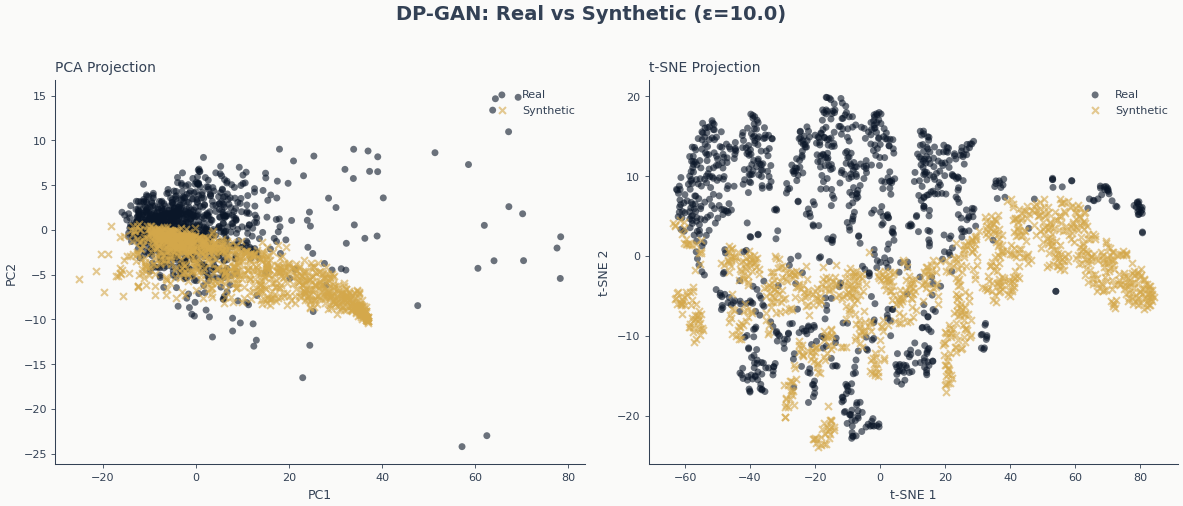

In [15]:
fig = plot_fidelity_comparison(
    real_data[:N_GENERATE],
    synthetic_data,
    title=f"DP-GAN: Real vs Synthetic (ε={history['epsilon'][-1]:.1f})",
    n_samples=min(1000, N_GENERATE),
)
plt.show()

**Interpretation**: With differential privacy, the generator adds calibrated noise
to protect individual training records. This typically results in less tight
overlap between real and synthetic distributions compared to non-private GANs.
The trade-off is intentional: stronger privacy guarantees (lower ε) mean more
noise and less fidelity. The quantitative metrics below measure this trade-off.

## 8. Evaluate Synthetic Data Quality

In [16]:
def evaluate_quality(real: np.ndarray, synthetic: np.ndarray) -> dict:
    """Evaluate synthetic data quality."""
    results = {}

    # Statistical comparison per feature
    print("\n" + "=" * 70)
    print("REAL vs DP-SYNTHETIC COMPARISON")
    print("=" * 70)
    print(
        f"{'Feature':<15} {'Real Mean':>12} {'Synth Mean':>12} {'Real Std':>12} {'Synth Std':>12}"
    )
    print("-" * 70)

    for i, name in enumerate(feature_names):
        real_mean = real[:, i].mean()
        synth_mean = synthetic[:, i].mean()
        real_std = real[:, i].std()
        synth_std = synthetic[:, i].std()
        print(
            f"{name:<15} {real_mean:>12.4f} {synth_mean:>12.4f} {real_std:>12.4f} {synth_std:>12.4f}"
        )

    # Overall metrics
    results["mean_diff"] = np.mean(np.abs(real.mean(axis=0) - synthetic.mean(axis=0)))
    results["std_diff"] = np.mean(np.abs(real.std(axis=0) - synthetic.std(axis=0)))

    # Correlation preservation (handle NaN from zero-variance features)
    corr_real = np.corrcoef(real, rowvar=False)
    corr_synth = np.corrcoef(synthetic, rowvar=False)
    corr_real = np.nan_to_num(corr_real, nan=0.0)
    corr_synth = np.nan_to_num(corr_synth, nan=0.0)
    results["corr_diff"] = np.linalg.norm(corr_real - corr_synth, "fro") / corr_real.size

    print("-" * 70)
    print(f"Mean absolute difference: {results['mean_diff']:.4f}")
    print(f"Std absolute difference: {results['std_diff']:.4f}")
    print(f"Correlation distance (Frobenius): {results['corr_diff']:.4f}")

    return results

### Run Quality Evaluation

In [17]:
quality = evaluate_quality(real_data[:N_GENERATE], synthetic_data)


REAL vs DP-SYNTHETIC COMPARISON
Feature            Real Mean   Synth Mean     Real Std    Synth Std
----------------------------------------------------------------------
ret_1d                0.0612      -0.8641       1.5400       0.9943
ret_5d                0.2991      -3.7306       3.2055       2.9688
volatility           21.1450      30.1601      12.3884      15.5704
volume_ratio          1.0136       0.7109       0.3496       0.6169
momentum_z            0.3428      -0.7961       1.2762       1.0168
range_pct             1.5847       0.1559       1.0874       0.7812
----------------------------------------------------------------------
Mean absolute difference: 2.8067
Std absolute difference: 0.7996
Correlation distance (Frobenius): 0.1204


## 8. Visualize Training and Results

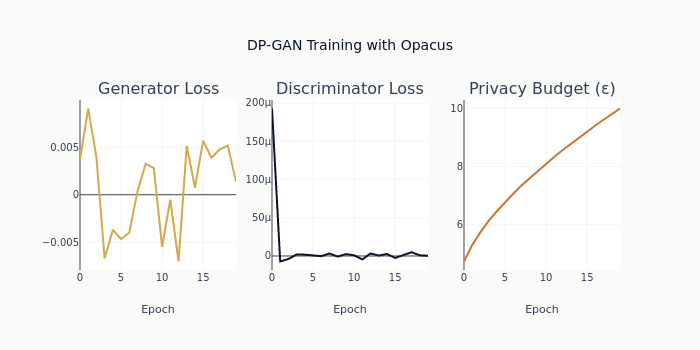

In [18]:
# Training curves with privacy tracking
fig = make_subplots(
    rows=1, cols=3, subplot_titles=["Generator Loss", "Discriminator Loss", "Privacy Budget (ε)"]
)

fig.add_trace(
    go.Scatter(y=history["g_loss"], mode="lines", name="G Loss", line_color=COLORS["amber"]),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(y=history["d_loss"], mode="lines", name="D Loss", line_color=COLORS["blue"]),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(y=history["epsilon"], mode="lines", name="ε spent", line_color=COLORS["copper"]),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Epoch")
fig.update_layout(
    title="DP-GAN Training with Opacus", height=350, showlegend=False, template="ml4t"
)
fig.show()

**Interpretation**: The loss curves reveal the tension between adversarial training and
privacy noise. Unlike standard GANs where losses stabilize, DP-GAN losses remain noisier
because Opacus injects calibrated Gaussian noise into every gradient step. The epsilon
trajectory in the right panel shows privacy budget consumption -- it increases monotonically
because each training step spends a fraction of the total budget. Faster epsilon growth
means more information is being extracted from the real data per step.

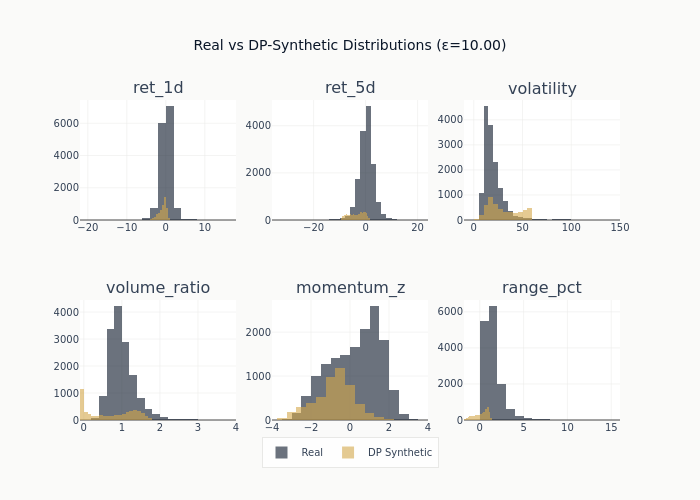

In [19]:
# Distribution comparison
n_features_to_plot = min(6, len(feature_names))
fig = make_subplots(
    rows=2, cols=3, subplot_titles=[feature_names[i] for i in range(n_features_to_plot)]
)

positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]
for i, (row, col) in enumerate(positions[:n_features_to_plot]):
    fig.add_trace(
        go.Histogram(
            x=real_data[:, i],
            name="Real",
            opacity=0.6,
            marker_color=COLORS["blue"],
            nbinsx=30,
            legendgroup="real",
            showlegend=(i == 0),
        ),
        row=row,
        col=col,
    )
    fig.add_trace(
        go.Histogram(
            x=synthetic_data[:, i],
            name="DP Synthetic",
            opacity=0.6,
            marker_color=COLORS["amber"],
            nbinsx=30,
            legendgroup="synthetic",
            showlegend=(i == 0),
        ),
        row=row,
        col=col,
    )

fig.update_layout(
    title=f"Real vs DP-Synthetic Distributions (ε={history['epsilon'][-1]:.2f})",
    height=500,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=-0.15, xanchor="center", x=0.5),
    barmode="overlay",
    template="ml4t",
)
fig.show()

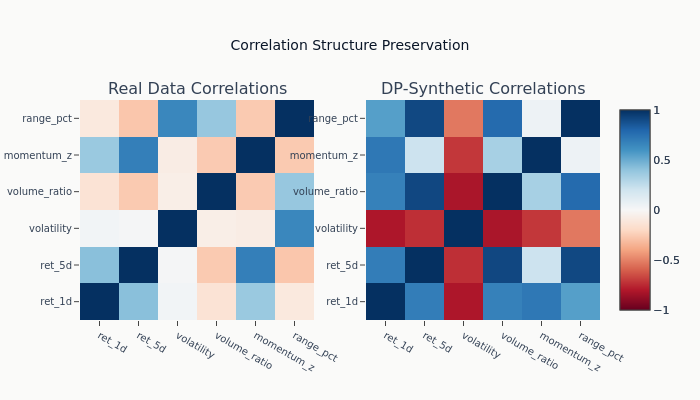

In [20]:
# Correlation heatmaps
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Real Data Correlations", "DP-Synthetic Correlations"]
)

corr_real = np.corrcoef(real_data, rowvar=False)
corr_synth = np.corrcoef(synthetic_data, rowvar=False)

fig.add_trace(
    go.Heatmap(z=corr_real, x=feature_names, y=feature_names, colorscale="RdBu", zmid=0),
    row=1,
    col=1,
)
fig.add_trace(
    go.Heatmap(z=corr_synth, x=feature_names, y=feature_names, colorscale="RdBu", zmid=0),
    row=1,
    col=2,
)

fig.update_layout(title="Correlation Structure Preservation", height=400, template="ml4t")
fig.show()

**Interpretation**: The correlation heatmaps show how well DP training preserves
cross-feature dependencies. Strong diagonal dominance in the difference would indicate
that marginal distributions are captured but joint structure is lost -- a common failure
mode when privacy noise drowns out the weaker inter-feature signals. At moderate epsilon
values (5-10), the generator typically captures the strongest correlations (e.g.,
returns vs. momentum) but struggles with subtle relationships (e.g., volume ratio vs.
volatility), which require more training signal than the privacy budget allows.

## 9. Privacy-Utility Trade-off Analysis

Let's see how different privacy budgets affect synthetic data quality.

In [21]:
# Run trade-off analysis
epsilon_values = [1.0, 5.0, 10.0, 50.0]
tradeoff_results = []

print("\n" + "=" * 60)
print("PRIVACY-UTILITY TRADE-OFF ANALYSIS")
print("=" * 60)

for eps in epsilon_values:
    print(f"\n--- Testing ε = {eps} ---")

    # Fresh models
    gen = Generator(CONFIG["latent_dim"], CONFIG["hidden_dim"], input_dim).to(device)
    disc = Discriminator(input_dim, CONFIG["hidden_dim"]).to(device)
    disc = ModuleValidator.fix(disc).to(device)

    # Quick training (fewer epochs)
    _, _ = train_dp_gan(
        generator=gen,
        discriminator=disc,
        train_loader=train_loader,
        epochs=10,
        target_epsilon=eps,
        target_delta=CONFIG["delta"],
        max_grad_norm=CONFIG["max_grad_norm"],
    )

    # Evaluate
    synth = generate_samples(gen, 1000)
    q = evaluate_quality(real_data[:1000], synth)
    tradeoff_results.append({"epsilon": eps, **q})


PRIVACY-UTILITY TRADE-OFF ANALYSIS

--- Testing ε = 1.0 ---


/opt/ml4t/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/opt/ml4t/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
06/14/2026 16:59:16:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.



Opacus privacy parameters:
  Noise multiplier: 1.1621
  Max grad norm: 1.0
  Target: (ε=1.0, δ=1e-05)


Training DP-GAN:   0%|          | 0/10 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


...

Training DP-GAN:  80%|████████  | 8/10 [00:09<00:02,  1.18s/it]

Training DP-GAN:  90%|█████████ | 9/10 [00:10<00:01,  1.15s/it]

Training DP-GAN: 100%|██████████| 10/10 [00:11<00:00,  1.17s/it]

Training DP-GAN: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]

Epoch 10/10 | G: 0.0061 | D: 0.0000 | ε: 49.99

Final privacy guarantee: (ε=49.99, δ=1e-05)

REAL vs DP-SYNTHETIC COMPARISON
Feature            Real Mean   Synth Mean     Real Std    Synth Std
----------------------------------------------------------------------
ret_1d                0.0554       1.3427       1.4277       1.0106
ret_5d                0.2645      -0.8604       2.8989       6.9716
volatility           18.9346      13.0581      12.6629      26.9217
volume_ratio          1.0133       0.8640       0.3482       0.6486
momentum_z            0.3808       0.8401       1.2741       0.6144
range_pct             1.4314       1.6994       1.0432       1.3343
----------------------------------------------------------------------
Mean absolute difference: 1.5275
Std absolute difference: 3.3334
Correlation distance (Frobenius): 0.1176


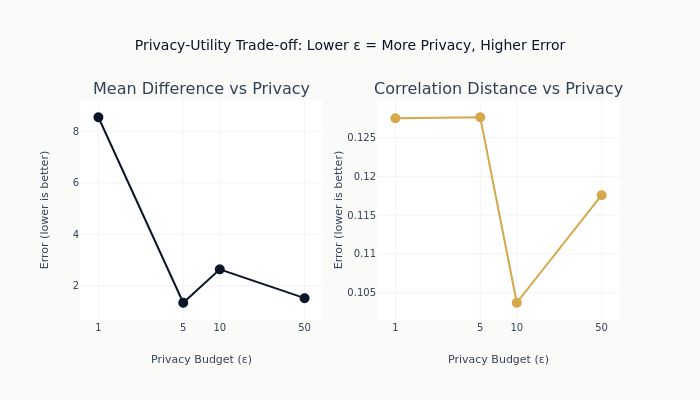

In [22]:
# Plot trade-off
results_df = pl.DataFrame(tradeoff_results)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Mean Difference vs Privacy", "Correlation Distance vs Privacy"],
)

fig.add_trace(
    go.Scatter(
        x=results_df["epsilon"].to_list(),
        y=results_df["mean_diff"].to_list(),
        mode="lines+markers",
        marker=dict(size=10),
        line_color=COLORS["blue"],
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=results_df["epsilon"].to_list(),
        y=results_df["corr_diff"].to_list(),
        mode="lines+markers",
        marker=dict(size=10),
        line_color=COLORS["amber"],
    ),
    row=1,
    col=2,
)

fig.update_xaxes(
    title_text="Privacy Budget (ε)",
    type="log",
    tickvals=[1, 5, 10, 50],
    ticktext=["1", "5", "10", "50"],
)
fig.update_yaxes(title_text="Error (lower is better)")
fig.update_layout(
    title="Privacy-Utility Trade-off: Lower ε = More Privacy, Higher Error",
    height=400,
    showlegend=False,
    template="ml4t",
)
fig.show()

**Interpretation**: The trade-off curves quantify the fundamental tension in differential
privacy: stronger guarantees (lower epsilon) require more noise per gradient step, which
degrades the generator's ability to learn distributional structure. The log-scale x-axis
reveals that quality improvements are roughly logarithmic in epsilon -- doubling the privacy
budget from 5 to 10 yields far less improvement than doubling from 1 to 2. For financial
applications, this means practitioners must decide: is the marginal quality gain from
epsilon=50 vs. epsilon=10 worth the weaker privacy guarantee? In regulated settings
(e.g., sharing client trading data), epsilon <= 10 is typically the ceiling.

## Key Takeaways

1. **Privacy-utility tradeoff is fundamental**: Stronger privacy guarantees (lower
   epsilon) inject more noise into gradients, degrading synthetic data quality. The
   tradeoff is roughly logarithmic -- quality improves rapidly from epsilon=1 to 10
   but plateaus beyond that. For financial applications, epsilon in the 5-10 range
   typically offers a practical balance.

2. **Per-sample gradients via Opacus are essential**: Standard PyTorch clips the
   *batch* gradient, which does not bound any individual sample's contribution.
   Opacus computes per-sample gradients using `functorch`, clips each independently
   to `max_grad_norm`, then adds calibrated noise. Manual implementations of this
   are notoriously error-prone -- Opacus makes it correct by construction.

3. **Epsilon measures cumulative information leakage**: Each training step consumes
   a fraction of the privacy budget. The privacy accountant (Renyi DP) tracks this
   precisely. Once epsilon is spent, no further training is possible without weakening
   the guarantee. This is why `make_private_with_epsilon` calibrates noise to spread
   the budget evenly across epochs.

4. **Architecture constraints matter**: BatchNorm violates DP because it computes
   statistics across the batch, leaking information about other samples. GroupNorm
   and LayerNorm are DP-safe alternatives. Use `ModuleValidator` to check compatibility
   before training.

**Next**: Section 5.7 covers the full Fidelity-Utility-Privacy evaluation framework
that situates DP-GAN against the non-private generators in earlier notebooks.

**Book**: Chapter 5, Section 5.7 discusses differential privacy within the broader
FUP framework, including membership inference attacks and nearest-neighbor privacy
metrics that complement the formal epsilon guarantee.

In [23]:
# Save DP synthetic data (consistent with other generators)
output_dir = get_output_dir(5, "dp_gan")
output_dir.mkdir(parents=True, exist_ok=True)

# Save as parquet with feature names
synthetic_df = pl.DataFrame(synthetic_data, schema=feature_names)
output_path = output_dir / "dp_gan_samples.parquet"
synthetic_df.write_parquet(output_path)
print(f"\nSaved DP synthetic data to {output_path}")

# Also save metadata
metadata = {
    "epsilon": float(history["epsilon"][-1]),
    "delta": CONFIG["delta"],
    "n_samples": len(synthetic_data),
    "features": feature_names,
    "quality": quality,
}
print(f"Final privacy guarantee: (ε={metadata['epsilon']:.2f}, δ={metadata['delta']})")

print("\nDP-GAN notebook complete!")


Saved DP synthetic data to 05_synthetic_data/output/dp_gan/dp_gan_samples.parquet
Final privacy guarantee: (ε=10.00, δ=1e-05)

DP-GAN notebook complete!
